In [1]:
import pandas as pd
df = pd.read_csv('./casos_obitos_doencas_preexistentes.csv', sep=';')
df_new = df.dropna()
df_new.drop(columns=['data_inicio_sintomas','codigo_ibge', 'diagnostico_covid19'], inplace=True)

disease_columns = [
    'asma', 'cardiopatia', 'diabetes', 'doenca_hematologica',
    'doenca_hepatica', 'doenca_neurologica', 'doenca_renal',
    'imunodepressao', 'obesidade', 'outros_fatores_de_risco',
    'pneumopatia', 'puerpera', 'sindrome_de_down'
]

mask = (df[disease_columns] != 'IGNORADO').all(axis=1)

df_new = df_new[mask]

df_new = df_new.drop(columns=['nome_munic'])
df_new.replace({'SIM': 1, 'NÃO': 0, '1':1, '0': 0}, inplace = True)
df_new.head()

C:\Users\Luis Eletro\AppData\Local\Temp\ipykernel_131900\148072871.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.drop(columns=['data_inicio_sintomas','codigo_ibge', 'diagnostico_covid19'], inplace=True)
C:\Users\Luis Eletro\AppData\Local\Temp\ipykernel_131900\148072871.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_new = df_new[mask]
C:\Users\Luis Eletro\AppData\Local\Temp\ipykernel_131900\148072871.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new.replace({'SIM': 1, 'NÃO': 0, '1':1, '0': 0}, inplace = True)


,idade,cs_sexo,obito,asma,cardiopatia,diabetes,doenca_hematologica,doenca_hepatica,doenca_neurologica,doenca_renal,imunodepressao,obesidade,outros_fatores_de_risco,pneumopatia,puerpera,sindrome_de_down
4657,82.0,MASCULINO,1,0,0,1,0,0,0,0,0,0,1,0,0,0
4658,30.0,FEMININO,1,0,0,1,0,0,0,0,0,1,0,0,0,0
4659,32.0,MASCULINO,1,0,1,0,0,0,0,0,0,0,1,0,0,0
4660,69.0,MASCULINO,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4661,78.0,MASCULINO,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [2]:
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(df_new[['cs_sexo']])
encoded_df = pd.DataFrame(encoded_data, columns=['F', 'M'], index=df_new.index)
df_new.drop(columns=['cs_sexo'], inplace=True)
df_new = pd.concat([encoded_df, df_new], axis = 1)

In [3]:
jovem, jovem_adulto, adulto = (df_new['idade']<30), ((df_new['idade']>20)&(df_new['idade']<40)), ((df_new['idade']>40)&(df_new['idade']<60))
senior, idoso = ((df_new['idade']>60)&(df_new['idade']<80)), (df_new['idade']>80)



--- Treinando modelo Random Forest para o grupo: jovem ---
Formato dos dados de treino: (5694, 16)
Formato dos dados de teste: (1424, 16)


Começando o Grid Search para o grupo: jovem
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.577 total time=   0.0s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.587 total time=   0.0s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.575 total time=   0.0s
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.577 total time=   0.1s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.586 total time=   0.1s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.579 total time=   0.1s
[CV 1/3] END max_depth=None, min_sa

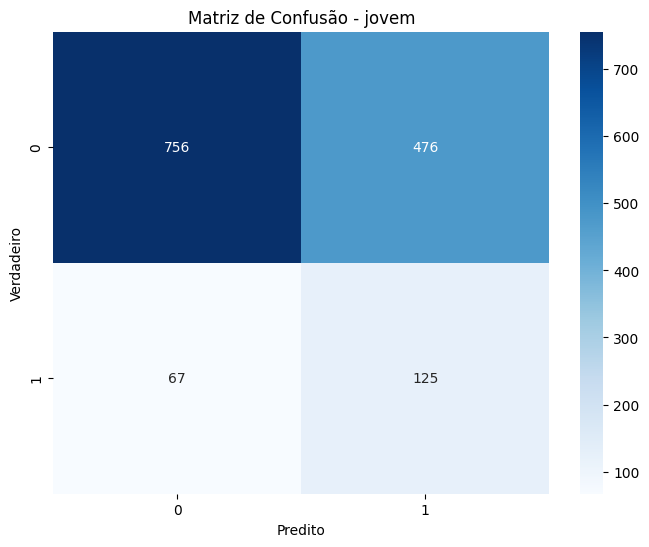

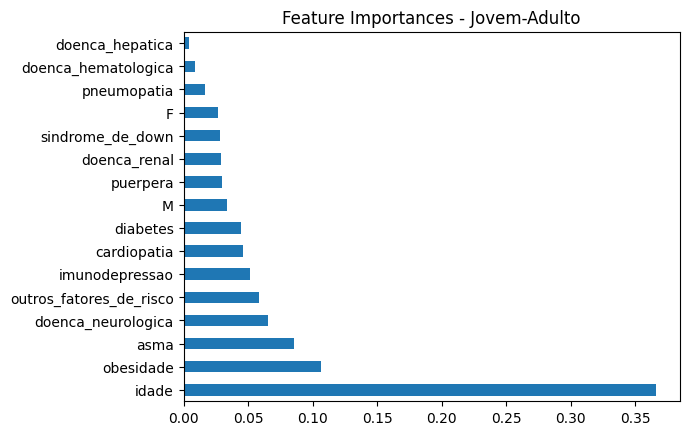



--- Treinando modelo Random Forest para o grupo: jovem-adulto ---
Formato dos dados de treino: (13553, 16)
Formato dos dados de teste: (3389, 16)


Começando o Grid Search para o grupo: jovem-adulto
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.532 total time=   0.1s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.532 total time=   0.1s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.555 total time=   0.1s
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.534 total time=   0.2s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.531 total time=   0.2s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.555 total time=   0.2s
[CV 1/3] END max_dep

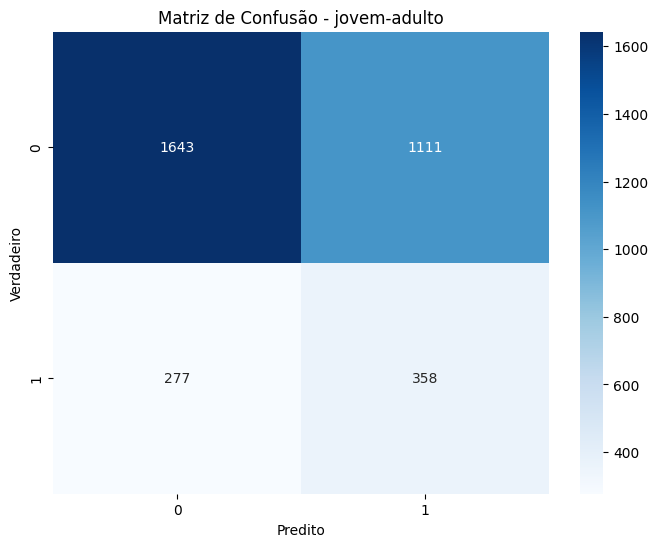

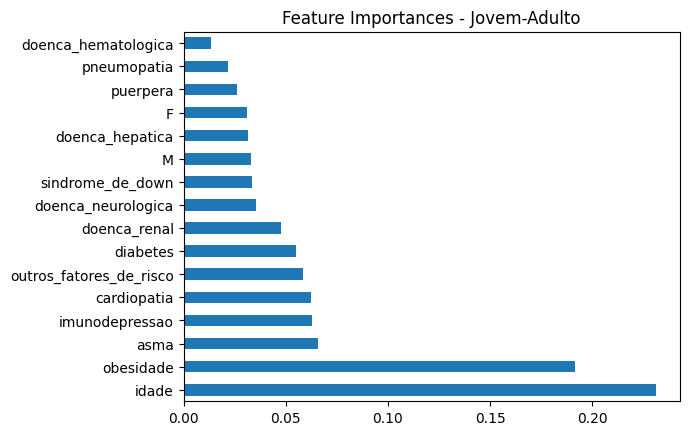



--- Treinando modelo Random Forest para o grupo: adulto ---
Formato dos dados de treino: (48644, 16)
Formato dos dados de teste: (12162, 16)


Começando o Grid Search para o grupo: adulto
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.555 total time=   0.2s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.560 total time=   0.2s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.557 total time=   0.2s
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.555 total time=   0.5s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.560 total time=   0.4s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.557 total time=   0.4s
[CV 1/3] END max_depth=None, mi

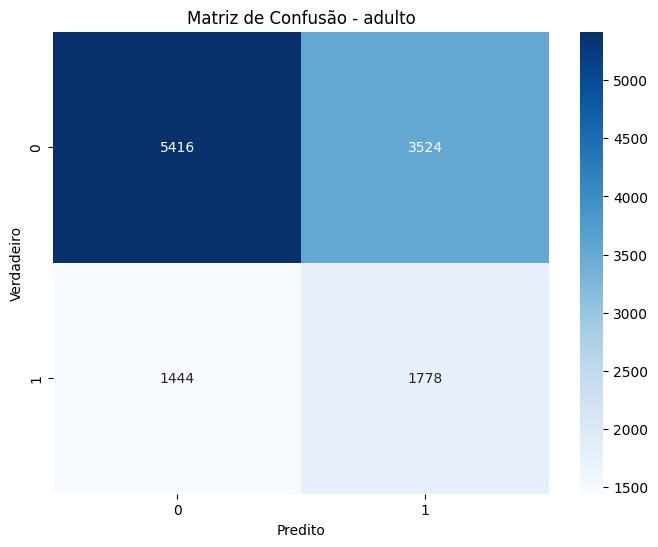

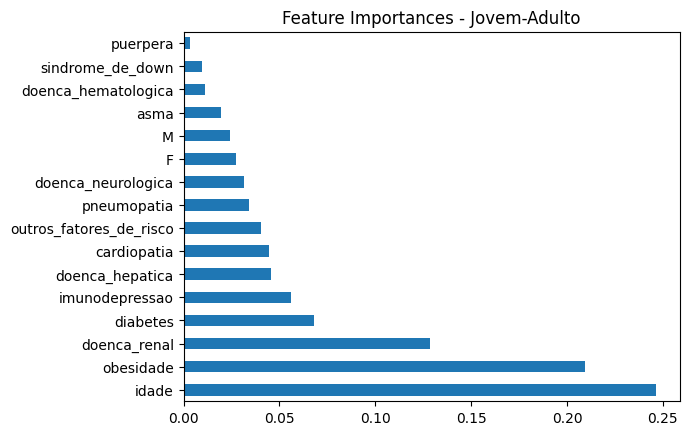



--- Treinando modelo Random Forest para o grupo: senior ---
Formato dos dados de treino: (65077, 16)
Formato dos dados de teste: (16270, 16)


Começando o Grid Search para o grupo: senior
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.553 total time=   0.2s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.555 total time=   0.2s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.553 total time=   0.2s
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.554 total time=   0.5s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.556 total time=   0.5s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.553 total time=   0.6s
[CV 1/3] END max_depth=None, mi

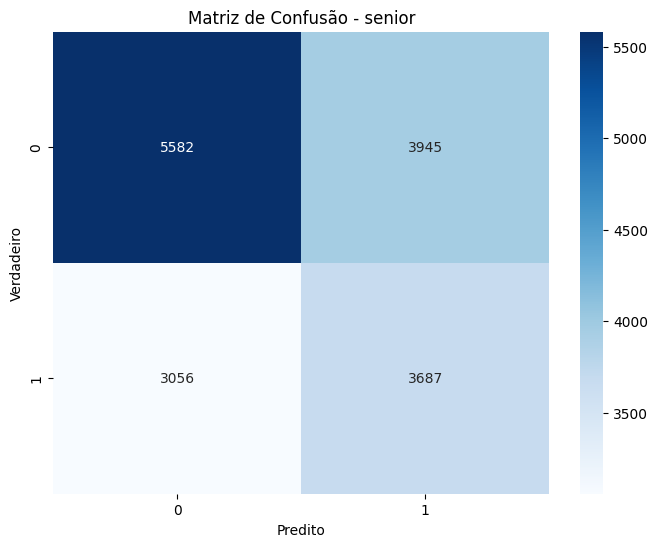

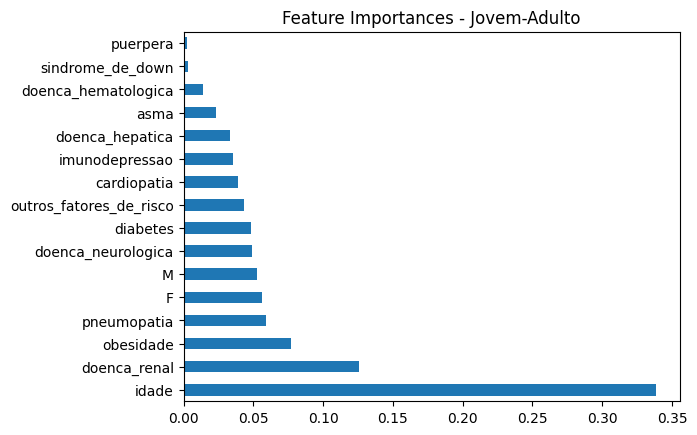



--- Treinando modelo Random Forest para o grupo: idoso ---
Formato dos dados de treino: (24293, 16)
Formato dos dados de teste: (6074, 16)


Começando o Grid Search para o grupo: idoso
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.536 total time=   0.1s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.530 total time=   0.1s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.536 total time=   0.1s
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.537 total time=   0.2s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.531 total time=   0.2s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.536 total time=   0.2s
[CV 1/3] END max_depth=None, min_s

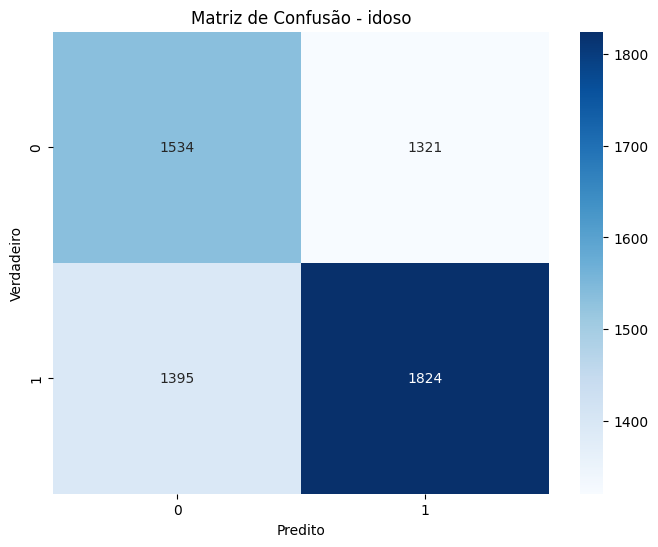

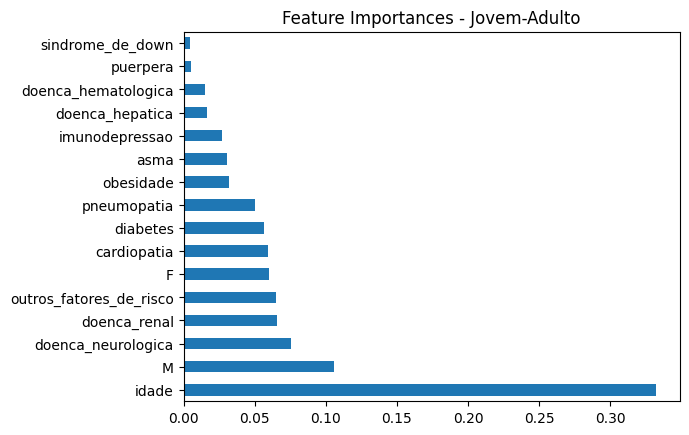

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

for group, group_name in zip([jovem, jovem_adulto, adulto, senior, idoso],
                             ['jovem', 'jovem-adulto', 'adulto', 'senior', 'idoso']):
    print(f"\n\n--- Treinando modelo Random Forest para o grupo: {group_name} ---")
    X = df_new[group].drop(columns=['obito'])
    y = df_new[group]['obito']

    scaler = MinMaxScaler()
    X['idade'] = scaler.fit_transform(X[['idade']])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Formato dos dados de treino: {X_train.shape}")
    print(f"Formato dos dados de teste: {X_test.shape}\n")

    rf_clf = RandomForestClassifier(
        criterion='entropy',
        random_state=42,
        class_weight='balanced',
        oob_score=True,
        n_jobs=10,
    )

    from sklearn.model_selection import GridSearchCV

    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    }

    print(f'\nComeçando o Grid Search para o grupo: {group_name}')
    grid_search = GridSearchCV(rf_clf, param_grid, cv=3, scoring="roc_auc", verbose=3)
    resultado = grid_search.fit(X_train, y_train)

    print("Melhores hiperparâmetros:", grid_search.best_params_)
    print("Maior AUC durante a validação cruzada:", grid_search.best_score_)
    print("AUC do conjunto de treino", grid_search.score(X_train, y_train))
    print("AUC do conjunto de teste:\n", grid_search.score(X_test, y_test))

    print(f'\nComeçando o treinamento final do modelo SVM para o grupo: {group_name}')
    rf_clf = RandomForestClassifier(
        n_estimators=grid_search.best_params_['n_estimators'],
        max_depth=grid_search.best_params_['max_depth'],
        min_samples_split=grid_search.best_params_['min_samples_split'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        criterion='entropy',
        random_state=42,
        class_weight='balanced',
        oob_score=True,
        n_jobs=10,
    )

    rf_clf.fit(X_train, y_train)
    y_pred_train = rf_clf.predict(X_train) # predição para o conjunto de treino
    y_pred_test = rf_clf.predict(X_test) # predição para o conjunto de teste

    # Métricas só para treino
    print("\nAcurácia - treino:", accuracy_score(y_train, y_pred_train))
    print("Acurácia - teste:", accuracy_score(y_test, y_pred_test))
    print("F1-Score - treino:", f1_score(y_train, y_pred_train, average='binary'))
    print("F1-Score - teste:", f1_score(y_test, y_pred_test))
    print('ROC-AUC - treino:', roc_auc_score(y_train, y_pred_train))
    print("ROC-AUC - teste:\n", roc_auc_score(y_test, y_pred_test))

    print("\n--- Relatório de Classificação ---")
    print(classification_report(y_test, y_pred_test))

    # 5. Matriz de Confusão
    print("\n--- Matriz de Confusão ---")
    print(confusion_matrix(y_test, y_pred_test))

    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_test, y_pred_test)

    labels = ['0', '1']

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Matriz de Confusão - '+group_name)
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.savefig('confusion_matrix_rf_'+group_name.replace('-','')+'.png')
    plt.show()

    importances = rf_clf.feature_importances_
    df_importancia = pd.Series(importances, index=X_test.columns).sort_values(ascending=False)
    df_importancia.plot.barh()
    plt.title("Feature Importances - Jovem-Adulto")
    plt.savefig('features_rf_'+group_name.replace('-','')+'.png')
    plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

group_name = 'todos'

print(f"\n\n--- Treinando modelo Random Forest para o grupo: {group_name} ---")
X = df_new.drop(columns=['obito'])
y = df_new['obito']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Formato dos dados de treino: {X_train.shape}")
print(f"Formato dos dados de teste: {X_test.shape}\n")

rf_clf = RandomForestClassifier(
    criterion='entropy',
    random_state=42,
    class_weight='balanced',
    n_jobs=10,
)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [20, 50, 100, 200, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

print(f'\nComeçando o Grid Search para o grupo: {group_name}')
grid_search = GridSearchCV(rf_clf, param_grid, cv=3, scoring="roc_auc", verbose=3)
resultado = grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Maior AUC durante a validação cruzada:", grid_search.best_score_)
print("AUC do conjunto de treino", grid_search.score(X_train, y_train))
print("AUC do conjunto de teste:\n", grid_search.score(X_test, y_test))

print(f'\nComeçando o treinamento final do modelo RF para o grupo: {group_name}')
rf_clf = RandomForestClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    criterion='entropy',
    random_state=42,
    class_weight='balanced',
    n_jobs=10,
)

rf_clf.fit(X_train, y_train)



--- Treinando modelo Random Forest para o grupo: todos ---
Formato dos dados de treino: (161463, 16)
Formato dos dados de teste: (40366, 16)


Começando o Grid Search para o grupo: todos
Fitting 3 folds for each of 180 candidates, totalling 540 fits
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=20;, score=0.617 total time=   0.1s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=20;, score=0.620 total time=   0.1s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=20;, score=0.622 total time=   0.1s
[CV 1/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.618 total time=   0.4s
[CV 2/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.620 total time=   0.4s
[CV 3/3] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.622 total time=   0.4s
[CV 1/3] END max_depth=None, min_s

,n_estimators,400
,criterion,'entropy'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Acurácia - treino: 0.6099849501124096
Acurácia - teste: 0.6096467323985533
F1-Score - treino: 0.5540376893496781
F1-Score - teste: 0.5545472535549713

--- Relatório de Classificação - teste ---
              precision    recall  f1-score   support

           0       0.76      0.57      0.65     25808
           1       0.47      0.67      0.55     14558

    accuracy                           0.61     40366
   macro avg       0.61      0.62      0.60     40366
weighted avg       0.65      0.61      0.62     40366


--- Matriz de Confusão - teste ---
[[14801 11007]
 [ 4750  9808]]


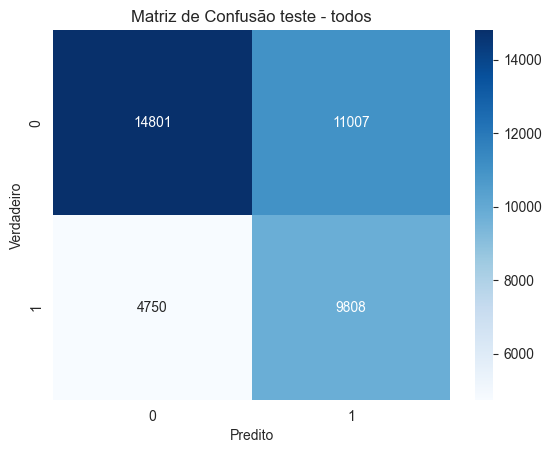

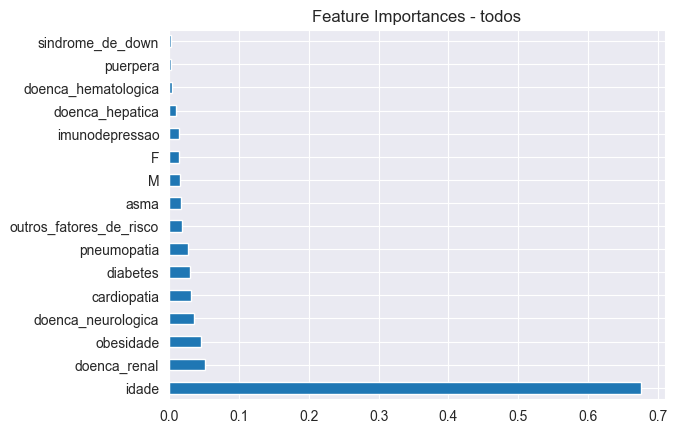



--- Avaliando modelo Random Forest para o grupo: jovem ---
Acurácia - jovem: 0.8655521213824108
F1-Score - jovem: 0.010341261633919338
ROC-AUC - jovem: 0.5024417762801775 


--- Relatório de Classificação - jovem ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      6158
           1       0.71      0.01      0.01       960

    accuracy                           0.87      7118
   macro avg       0.79      0.50      0.47      7118
weighted avg       0.85      0.87      0.80      7118


--- Matriz de Confusão - jovem ---
[[6156    2]
 [ 955    5]]


--- Avaliando modelo Random Forest para o grupo: jovem-adulto ---
Acurácia - jovem-adulto: 0.8140715381891158
F1-Score - jovem-adulto: 0.03136531365313653
ROC-AUC - jovem-adulto: 0.5070197816445348 


--- Relatório de Classificação - jovem-adulto ---
              precision    recall  f1-score   support

           0       0.81      1.00      0.90     13769
           1       0.65      

In [22]:


y_pred_train = rf_clf.predict(X_train) # predição para o conjunto de treino
y_pred_test = rf_clf.predict(X_test) # predição para o conjunto de teste
print("\nAcurácia - treino:", accuracy_score(y_train, y_pred_train))
print("Acurácia - teste:", accuracy_score(y_test, y_pred_test))
print("F1-Score - treino:", f1_score(y_train, y_pred_train, average='binary'))
print("F1-Score - teste:", f1_score(y_test, y_pred_test))
print("\n--- Relatório de Classificação - teste ---")
print(classification_report(y_test, y_pred_test))
# 5. Matriz de Confusão
print("\n--- Matriz de Confusão - teste ---")
print(confusion_matrix(y_test, y_pred_test))
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_teste = confusion_matrix(y_test, y_pred_test)

labels = ['0', '1']

sns.heatmap(cm_teste, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão teste - '+group_name)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()


importances = rf_clf.feature_importances_
df_importancia = pd.Series(importances, index=X_test.columns).sort_values(ascending=False)
df_importancia.plot.barh()
plt.title("Feature Importances - "+group_name)
plt.show()


for group, group_name in zip([jovem, jovem_adulto, adulto, senior, idoso],
                             ['jovem', 'jovem-adulto', 'adulto', 'senior', 'idoso']):
    print(f"\n\n--- Avaliando modelo Random Forest para o grupo: {group_name} ---")
    X_aux = df_new[group].drop(columns=['obito'])
    y_aux = df_new[group]['obito']

    y_pred_aux = rf_clf.predict(X_aux)

    print(f"Acurácia - {group_name}:", accuracy_score(y_aux, y_pred_aux))
    print(f"F1-Score - {group_name}:", f1_score(y_aux, y_pred_aux))
    print(f"ROC-AUC - {group_name}:", roc_auc_score(y_aux, y_pred_aux), '\n')

    print(f"\n--- Relatório de Classificação - {group_name} ---")
    print(classification_report(y_aux, y_pred_aux))

    # 5. Matriz de Confusão
    print(f"\n--- Matriz de Confusão - {group_name} ---")
    print(confusion_matrix(y_aux, y_pred_aux))

